# Машинное обучение, DS-поток
## Задание ML.10

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  200 баллов.


In [ ]:
# Bot check

# HW_ID: ds_ml10
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import base64
from IPython.display import Markdown, display
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

In [12]:
import os
import time
import warnings
from PIL import Image
from functools import lru_cache

import numpy as np

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A

from torchvision.models.feature_extraction import create_feature_extractor
from torchvision import models

RANDOM_STATE = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

Вы хорошо покушали перед выполнением задания?

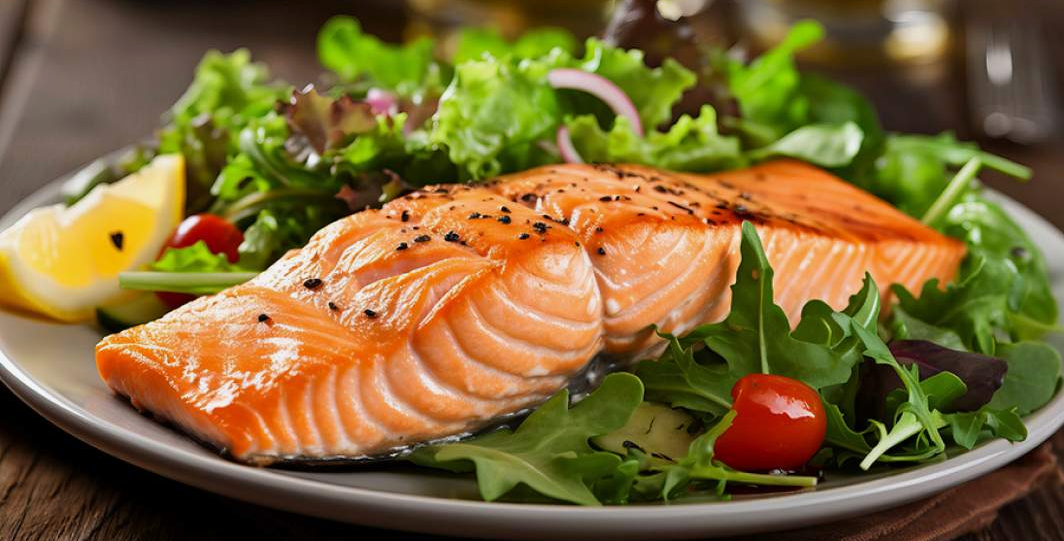

### Задача 1

Еда — одно из главных удовольствий, занимающее значительную часть нашей жизни. Чтобы совместить это наслаждение с осознанным подходом к питанию, мы применяем семантическую сегментацию, которая с пиксельной точностью определяет состав блюда по его фотографии.

В этом задании вам предстоит поработать с датасетом из [kaggle соревнования](https://www.kaggle.com/competitions/ds-3-2025-ml-10/data). На примере этой задачи вы проследите эволюцию популярных моделей сегментации, изучите основные лоссы и примените на практике технику TTA.

#### 1. Данные
В первую очередь подготовьте датасет.
* Разделите данные на трейн и валидаццию.
* Оберните данные в `Dataset` и добавьте аугментаций. Не забывайте, что аугментации также нужно применить к маске. В этом вам поможет библиотека `Albumentations`.
* Визуализируйте несколько примеров аугментированных данных.

In [14]:
print('Текущая директория:', os.getcwd())
data_path = "/content/drive/MyDrive/DScource/ML10/food"

Текущая директория: /home/kirill/Education/Python/DScource/ML10


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


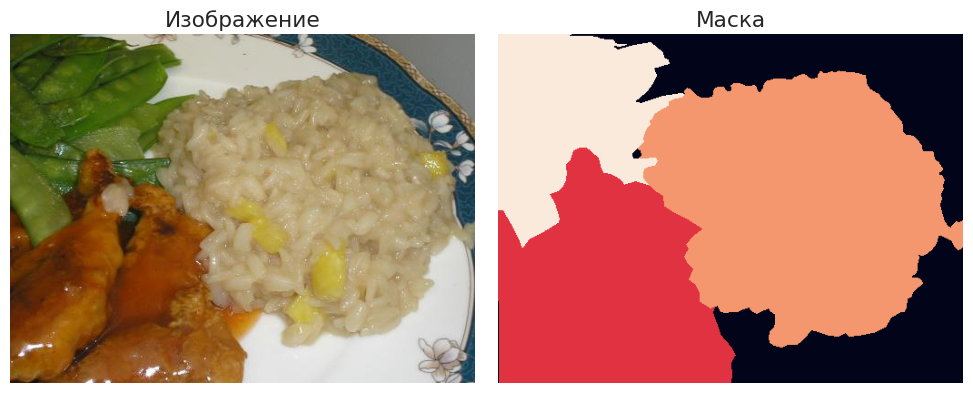

In [ ]:
image = Image.open(os.path.join(data_path, 'images/train/00000.jpg'))
mask = Image.open(os.path.join(data_path, 'masks/train/00000.png'))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Изображение")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Маска")
plt.imshow(mask)
plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
class FoodDataset(Dataset):
    def __init__(self, images_filenames, images_directory, masks_directory,  transform=None):
        '''Задаем аугментации и пути к картинкам и маскам'''
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.masks_directory = masks_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    @lru_cache(maxsize=100)
    def _get_image_mask(self, image_filename):
        '''Получим картинку и маску для файла image_filename'''
        # Считываем изображение
        image = np.array(Image.open(os.path.join(self.images_directory, image_filename)))

        # Считываем маску
        splitted = image_filename.split('.')
        mask_filename = splitted[0] + ".png"
        mask = np.array(Image.open(os.path.join(self.masks_directory, mask_filename)))
        return image, mask

    def __getitem__(self, idx):
        '''Получим картинку и маску индекса idx'''
        image_filename = self.images_filenames[idx]
        image, mask = self._get_image_mask(image_filename)

        # Применяем трансформацию (аугментацию)
        try:
            transformed = self.transform(image=image, mask=mask)
        except:
            print(image_filename)
            raise ValueError
        image = transformed["image"]
        mask = transformed["mask"]

        return np.moveaxis(image.astype(np.float32), 2, 0), mask.astype(np.float32)[None]


In [16]:
train_directory = os.path.join(data_path, "images/train")
train_masks_directory = os.path.join(data_path, "masks/train")
val_directory = train_directory
val_masks_directory = train_masks_directory

train_filenames = np.array(sorted(os.listdir(train_directory)))[1:]

inds = np.arange(len(train_filenames))
train_inds, val_inds = train_test_split(inds, test_size=0.2, random_state=RANDOM_STATE)
train_filenames, val_filenames = train_filenames[train_inds], train_filenames[val_inds]

test_directory = os.path.join(data_path, "images/test")
test_filenames = np.array(sorted(os.listdir(test_directory)))[1:]

print('Число файлов тренировочной выборки:', len(train_filenames))
print('Число файлов валидационной выборки:', len(val_filenames))

Число файлов тренировочной выборки: 3986
Число файлов валидационной выборки: 997


In [ ]:
vis_transform = A.Compose([
    A.ColorJitter(0.9, 0.9, 0.9, 0.1),
    A.Affine(rotate=5),
])

train_dataset = FoodDataset(train_filenames, train_directory, train_masks_directory, transform=vis_transform)

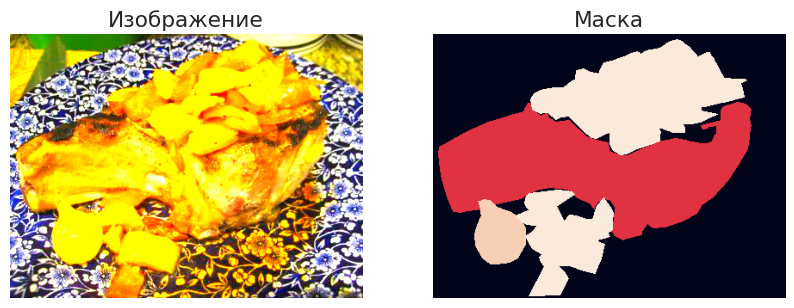

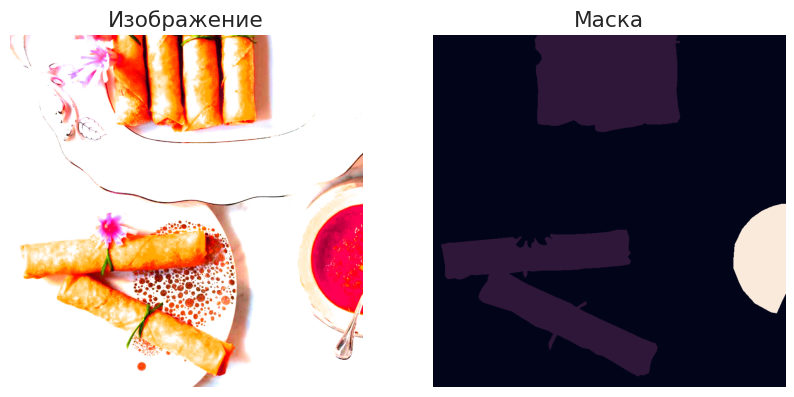

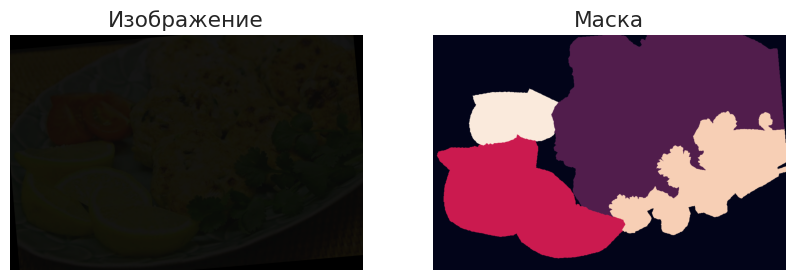

In [ ]:
for i in [0, 1, 2]:
    image, mask = train_dataset[i]
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Изображение")
    plt.imshow(np.moveaxis(image, 0, 2).astype(int))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Маска")
    plt.imshow(mask[0])
    plt.axis("off");

In [17]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.ColorJitter(0.9, 0.9, 0.9, 0.1),
    A.Affine(rotate=5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)),
])


train_dataset = FoodDataset(train_filenames, train_directory, train_masks_directory, transform=train_transform)
val_dataset = FoodDataset(val_filenames, val_directory, val_masks_directory, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 3986, Val samples: 997


In [61]:
train_subset = torch.utils.data.Subset(train_dataset, range(1024))
val_subset = torch.utils.data.Subset(val_dataset, range(128))

train_subloader = DataLoader(train_subset, batch_size=8, shuffle=True)
val_subloader = DataLoader(val_subset, batch_size=8, shuffle=False)

In [ ]:
all_classes = set()
for _, mask in tqdm(train_dataset):
    all_classes.update(np.unique(mask))
print("Количество классов:", len(all_classes))

  0%|          | 0/3986 [00:00<?, ?it/s]

Количество классов: 17


#### 2. Реализация моделей
Проследим эволюцию моделей сегментации на примере UPerNet. Последовательно реализуйте архитектуры следующих моделей:
- FCN (реализована в ноутбуке с занятия)
- UNET
- FPN
- UPerNet

В качестве энкодера используйте ResNet34 backbone.

### FCN

In [18]:
# Функция для получения бэкбона
def get_resnet34_backbone(pretrained=True):
    model = models.resnet34(pretrained=pretrained)
    return create_feature_extractor(model, {
        'layer1': 'feat1',
        'layer2': 'feat2',
        'layer3': 'feat3',
        'layer4': 'feat4'
    })

# Обертка модели
class SegmentationModelWrapper(nn.Module):
    def __init__(self, backbone, decoder, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone
        self.decoder = decoder

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone.eval()

    def forward(self, x):
        feats = self.backbone(x)
        x = self.decoder(feats, input_shape=x.shape[-2:])
        return x

In [19]:
class FCNDecoder(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        inter_channels = in_channels // 4
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(inter_channels),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(inter_channels, num_classes, 1),
        )


    def forward(self, feats, input_shape):
        x = self.head(feats['feat4'])
        x = F.interpolate(x, size=input_shape, mode='bilinear', align_corners=False)
        return x

In [20]:
backbone = get_resnet34_backbone(pretrained=True)
decoder = FCNDecoder(512, 17)
fcn = SegmentationModelWrapper(backbone, decoder, freeze_backbone=True)

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Unet

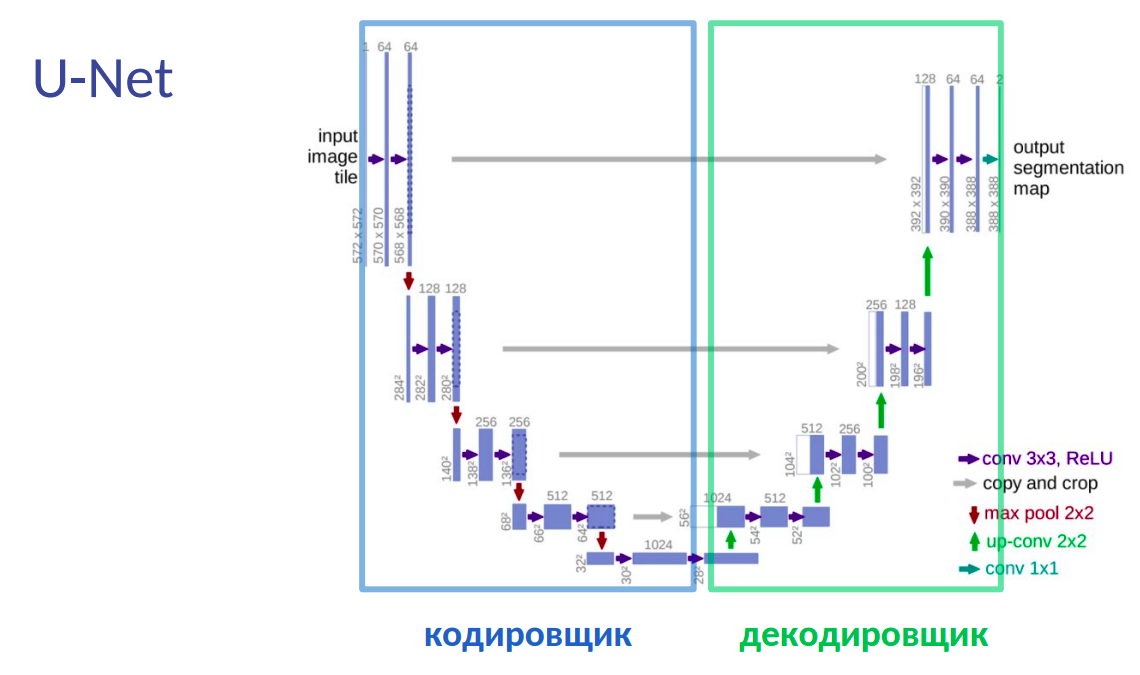

In [ ]:
#Не будем ресайзить до 572х572, оставлю 512х512 (на одном из шагов округлится вниз)
embed_image('1.png')

In [31]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3), #64*510*510
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3), #64*508*508
            nn.ReLU(),
            # nn.MaxPool2d(kernel_size=2, stride=2) #64*254*254
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3), #128*252*252
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3), # 128*250*260
            nn.ReLU(),
            # nn.MaxPool2d(kernel_size=2, stride=2) #128*125*125
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3), #256*123*123
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3), #256*121*121
            nn.ReLU(),
            # nn.MaxPool2d(kernel_size=2, stride=2) #256*60*60
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3), #512*58*58
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3), #512*56*56
            nn.ReLU(),
            # nn.MaxPool2d(kernel_size=2, stride=2) #512*28*28
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3), #1024*26*26
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3), #1024*24*24
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) #512*48*48
        #crop, concat
        self.deblock1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3), #512*46*46
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3), #512*44*44
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) #256*88*88
        #crop, concat
        self.deblock2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3), #256*86*86
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3), #256*84*84
            nn.ReLU()
        )

        self.up3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2) #128*168*168
        #crop, concat
        self.deblock3 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3), #128*166*166
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3), #128*164*164
            nn.ReLU()
        )

        self.up4 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2) #64*328*328
        #crop, concat
        self.deblock4 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3), #64*326*326
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3), #128*324*324
            nn.ReLU()
        )

        self.res = nn.Conv2d(8, 17, kernel_size=1)

    def center_crop(self, tensor, target_h, target_w):
        _, _, h, w = tensor.shape

        start_h = (h - target_h) // 2
        start_w = (w - target_w) // 2

        return tensor[:, :, start_h : start_h + target_h, start_w : start_w + target_w]

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(self.down(x1))
        x3 = self.block3(self.down(x2))
        x4 = self.block4(self.down(x3))
        x5 = self.block5(self.down(x4))

        y1 = self.up1(x5)
        y1 = self.deblock1(torch.cat((self.center_crop(x4, y1.shape[2], y1.shape[3]), y1), dim=1))
        y2 = self.up2(y1)
        y2 = self.deblock2(torch.cat((self.center_crop(x3, y2.shape[2], y2.shape[3]), y2), dim=1))
        y3 = self.up3(y2)
        y3 = self.deblock3(torch.cat((self.center_crop(x2, y3.shape[2], y3.shape[3]), y3), dim=1))
        y4 = self.up4(y3)
        y4 = self.deblock4(torch.cat((self.center_crop(x1, y4.shape[2], y4.shape[3]), y4), dim=1))

        out = self.res(y4)
        out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)

        return out


In [65]:
unet = Unet()

Какое архитектурное преимущество по сравнению с FCN дает UNet?

Благодаря skip-connections, Unet может улавливать более трудные геометрические расположения объектов

### FPN

...

### UPerNet

In [ ]:
...

В чем польза добавления Pyramid Pooling модуля?

...

#### 3. Обучение и исследование
* Обучите модели на нашем датасете, используя CrossEntropy Loss.
* Сравните модели по IoU и лоссу на валидации и трейне, постройте графики заивисимости мерик от эпохи.  
* Визуально проанализируйте качество сегментации фиксированных изображений для разных моделей.
* Сделайте выводы о том какая модель лучше и за счет чего достигается такое качество.

*Рекомендация*: постарайтесь написать код так, чтобы выбор лосса и модели делался сменой одной - двух переменных.

In [9]:
results = {}

In [10]:
# Функция для вычисления IoU
def calculate_iou(pred, target, num_classes=17):
    """
    Calculate Intersection over Union (IoU)
    pred: [B, C, H, W] probabilities
    target: [B, H, W] class indices
    """
    # Преобразуем предсказания в классы
    pred_class = torch.argmax(pred, dim=1)

    ious = []
    for class_id in range(num_classes):
        pred_mask = (pred_class == class_id)
        target_mask = (target == class_id)

        intersection = (pred_mask & target_mask).float().sum((1, 2))
        union = (pred_mask | target_mask).float().sum((1, 2))

        # Избегаем деления на ноль
        iou = (intersection + 1e-6) / (union + 1e-6)
        ious.append(iou.mean().item())

    return np.mean(ious)

In [11]:
# Функция для обучения и оценки
def train_and_evaluate(model, train_loader, test_loader, num_epochs=10):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_ious = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_loss = 0
        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images = images.to(device)
            masks = masks.to(device).squeeze(1).long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluation
        model.eval()
        total_iou = 0
        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                masks = masks.to(device).squeeze(1).long()

                outputs = model(images)
                iou = calculate_iou(outputs, masks)
                total_iou += iou

        avg_iou = total_iou / len(test_loader)
        test_ious.append(avg_iou)

        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, IoU = {avg_iou:.4f}')
        
    return train_losses, test_ious

### FCN

In [ ]:
start_time = time.time()
train_losses, test_ious = train_and_evaluate(fcn, train_subloader, val_loader, num_epochs=5)
end_time = time.time()

Epoch 1/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1: Loss = 1.3529, IoU = 0.7049


Epoch 2/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2: Loss = 1.1052, IoU = 0.7097


Epoch 3/5:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 4/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 4: Loss = 1.0391, IoU = 0.7028


Epoch 5/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 5: Loss = 1.0135, IoU = 0.6873


NameError: name 'results' is not defined

In [ ]:
results['FCN'] = {
    'train_losses': train_losses,
    'test_ious': test_ious,
    'training_time': end_time - start_time,
    'final_iou': test_ious[-1]
}

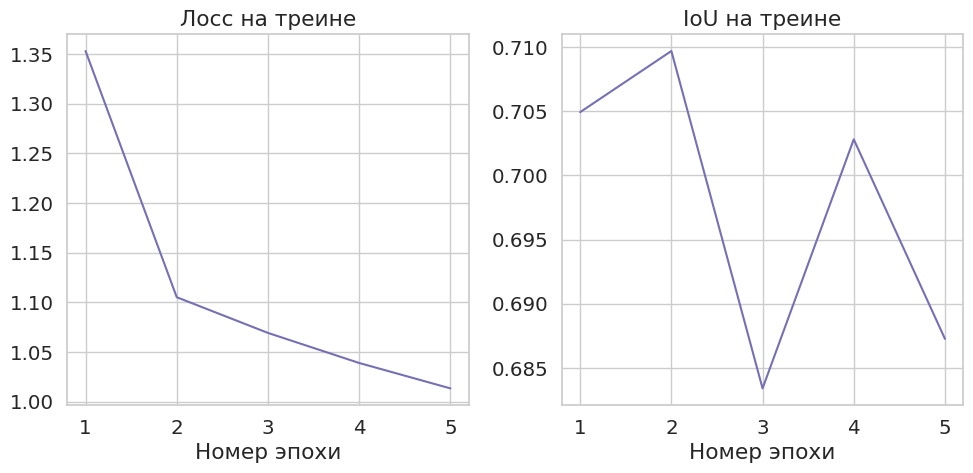

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), results['FCN']['train_losses'])
plt.title('Лосс на треине')
plt.xlabel('Номер эпохи')
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), results['FCN']['test_ious'])
plt.title('IoU на треине')
plt.xlabel('Номер эпохи')
plt.tight_layout()
plt.show()

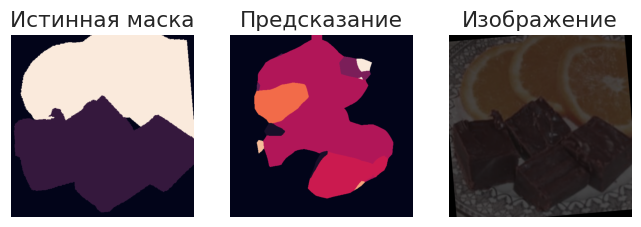

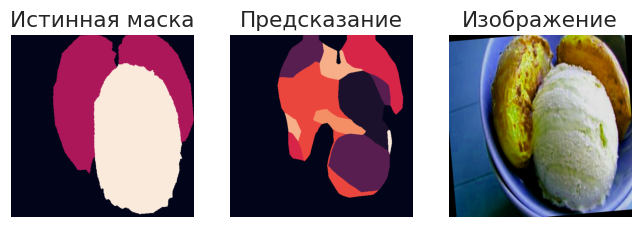

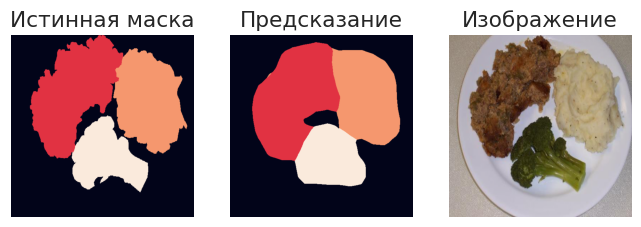

In [ ]:
it = iter(train_loader)
images, masks = next(it)

outputs = fcn(images.to(device))
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

for i in range(3):
    plt.figure(figsize=(8, 5))

    plt.subplot(1, 3, 1)
    plt.axis('off')
    plt.title('Истинная маска')
    plt.imshow(masks[i][0])

    plt.subplot(1, 3, 2)
    plt.axis('off')
    plt.title('Предсказание')
    plt.imshow(outputs[i].argmax(dim=0).cpu())

    plt.subplot(1, 3, 3)
    plt.axis('off')
    plt.title('Изображение')
    plt.imshow((images[i] * std + mean).permute(1, 2, 0))

### Unet

In [66]:
start_time = time.time()
train_losses, test_ious = train_and_evaluate(unet, train_subloader, val_subloader, num_epochs=5)
end_time = time.time()
torch.save(unet.state_dict(), 'unet.pth')

Epoch 1/5:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1: Loss = 2.2806, IoU = 0.7899


Epoch 2/5:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2: Loss = 1.9329, IoU = 0.7899


Epoch 3/5:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 3: Loss = 1.9212, IoU = 0.7899


Epoch 4/5:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 4: Loss = 1.9161, IoU = 0.7899


Epoch 5/5:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 5: Loss = 1.9147, IoU = 0.7899


In [103]:
results['Unet'] = {
    'train_losses': train_losses,
    'test_ious': test_ious,
    'training_time': end_time - start_time,
    'final_iou': test_ious[-1]
}

In [21]:
it = iter(train_subloader)
images, masks = next(it)

outputs = unet(images.to(device))
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

for i in range(3):
    plt.figure(figsize=(8, 5))

    plt.subplot(1, 3, 1)
    plt.axis('off')
    plt.title('Истинная маска')
    plt.imshow(masks[i][0])

    plt.subplot(1, 3, 2)
    plt.axis('off')
    plt.title('Предсказание')
    plt.imshow(outputs[i].argmax(dim=0).cpu())

    plt.subplot(1, 3, 3)
    plt.axis('off')
    plt.title('Изображение')
    plt.imshow((images[i] * std + mean).permute(1, 2, 0))

NameError: name 'train_subloader' is not defined

**Выводы:**
...


#### 4. Лоссы
Сравните как функция потерь влияет на итоговое качество модели. Для лучшей модели поставьте эксперименты с со следующимим лоссами:
- DiceLoss,
- линейную комбинацию CrossEntropy и DiceLoss,
- линейную комбинацию CrossEntropy и LovaszLoss.

Коэффициенты в линейной комбинации можно изменять с теченим эпох.

**Выводы:**
...

#### 5. TTA
Реализуйте TTA (Test Time Augmentation): примените аугментации для каждого изображения из валидации, сагрегируйте реазультатыт. Можно, например, взять аугментации для обучающей выборки, но для снижения дисперсии уменьшить вероятности аугментаций.

In [ ]:
...

**Выводы:**

...

---
### Задача 2

#### Сегментация блюда
Вы просыпаетесь в неизвестной комнате. Темно. Лишь свет одинокой лампочки под потолком освещает невнятные контуры предметов вокруг. Очень хочется есть. Посередине комнаты стоит стол, на нём &mdash; тарелка с неизвестным блюдом. Выглядит очень аппетитно, но съедобно ли это? Если бы вы только знали, из чего оно...

**Ваша задача:** разработать ML-модель, которая сможет определить, из чего состоит блюдо, только по его фотографии. По ощущениям, вы не ели уже несколько дней, так что нужно сделать это как можно быстрее. Что ж, время пошло.

Ваша задача &mdash; сегментировать изображение.

**Метрика соревнования:** IoU

Ссылка: https://www.kaggle.com/competitions/ds-3-2025-ml-10/

Приглашение: https://www.kaggle.com/t/64c0e06e1c434819ad8ca43fbbe2ded0

**📋 Правила**

* В Kaggle в данное тренировочное соревнование можно отправлять не более 10 решений в день (11-ю система не позволит).
* Решения индивидуальные.
* Качество считается по метрике Accuracy.
* До окончания соревнования доступны значения качества, посчитанные только на случайных 40% тестовых данных. Значения отображаются в Public Leaderboard.
* После окончания соревнования становится доступным Private Leaderboard, в котором значения качества посчитанны на оставшихся 60% объектов.
* Для включения в Private Leaderboard можно выбрать две посылки.
* В Leaderboard должны отображаться ваши **реальные имя и фамилия**. В противном случае решение может быть не зачтено.
* Все файлы, которые вы отправляете в соревнование, видны организаторам соревнования. Файлы должны иметь понятное имя, при отправке файла в систему необходимо написать краткое описание решения. **Это будет проверяться.**
* В решении, отправляемом боту, должно быть отображено, результаты каких моделей вы отправляете в соревнование.
* Не забывайте сделать пояснения к своему решению. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* Пользоваться можно любыми пройденными в наших курсах моделями.
* Нельзя пользоваться любыми методами и моделями, которые мы не проходили, и которых не было в ранее в иных курсах, которые обязательны для всех.
* Код студентов, занявших первые 3 места, будет запускаться. Также выборочно может запускаться код и остальных студентов.


#### Submission-файл
Для каждого файла из тестовой выборки предскажите маску в формате rle. Используйте код ниже для кодирования torch-маски размером `H * W` в этот формат:

``` python
def rle_encode(mask):
    """
    Кодирует бинарную маску в RLE (run-length encoding).
    Возвращает строку вида 'start length start length ...'
    """
    pixels = np.array(mask).flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

def encode_multiclass_mask(mask):
    """
    Кодирует небинарную маску в словарь RLE-кодировок по классам.
    """
    rles = {}
    for cls in np.unique(mask):
        if cls == 0:
            continue  # 0 обычно фон
        binary_mask = np.array(mask == cls).astype(np.uint8)
        rles[int(cls)] = rle_encode(binary_mask)
    return rles
```

id должен быть в формате `{имя файла}_{класс}`. Пример файла-сабмита:

```
id,mask
00000.jpg_0,15837 8 16149 2 16156...
00000.jpg_1,15837 8 16149 2 16156...
00000.jpg_2,15837 8 16149 2 16156...
00000.jpg_3,15837 8 16149 2 16156...
00000.jpg_4,15837 8 16149 2 16156...
00000.jpg_5,15837 8 16149 2 16156...
00000.jpg_6,15837 8 16149 2 16156...
00000.jpg_7,15837 8 16149 2 16156...
00000.jpg_8,15837 8 16149 2 16156...
00000.jpg_9,15837 8 16149 2 16156...
00000.jpg_10,15837 8 16149 2 16156...
00000.jpg_11,15837 8 16149 2 16156...
00000.jpg_12,15837 8 16149 2 16156...
00000.jpg_13,15837 8 16149 2 16156...
00000.jpg_14,15837 8 16149 2 16156...
00000.jpg_15,15837 8 16149 2 16156...
00000.jpg_16,15837 8 16149 2 16156...
00001.jpg_0,15837 8 16149 2 16156...
00001.jpg_1,15837 8 16149 2 16156...
00001.jpg_2,15837 8 16149 2 16156...
00001.jpg_3,15837 8 16149 2 16156...
...
```


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока